# Detector-level 2 m SCAO

**Scientific question.** Scaled up to a 2 m telescope with a detector-level
Shack–Hartmann sensor running with photon and read noise, does the *same*
shared `shwfs_ao.control.run_closed_loop` engine used in `high_order_scao.ipynb`
still deliver a stable, noise-included correction — and what near-infrared
Strehl does it reach?

This is the higher-fidelity companion to the high-order study: identical loop
engine, larger aperture, and detector noise switched on.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
WFS_WAVELENGTH_M = 700e-9
SCIENCE_WAVELENGTH_M = 1.65e-6
PUPIL_PIXELS = 96 if FAST_SMOKE else 120
N_LENSLETS_ACROSS = 8 if FAST_SMOKE else 10
N_ACTUATORS_ACROSS = 7 if FAST_SMOKE else 9
N_STEPS = 6 if FAST_SMOKE else 16

## Configuration

In [4]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
    n_lenslets_across=N_LENSLETS_ACROSS,
    min_fill_fraction=0.4,
)
pupil = geometry.pupil_geometry
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=3e4, read_noise_e=2.0),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=N_ACTUATORS_ACROSS,
        coupling_width_pitch=0.35,
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=30e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
atmosphere = FrozenFlowAtmosphere(
    FrozenFlowAtmosphereConfig(
        grid_size=geometry.pupil_shape[0],
        delta_m=pupil.pixel_spacing_xy_m[0],
        pupil_diameter_m=TELESCOPE_DIAMETER_M,
        r0_m=0.18,
        outer_scale_m=25.0,
        wind_m_per_s=(9.0, 0.0),
        root_seed=SEED,
    ),
    pupil_mask=geometry.pupil_mask,
)
print(f"D/r0 = {TELESCOPE_DIAMETER_M / 0.18:.1f}; {int(mirror.n_actuators)} active actuators")

D/r0 = 11.1; 49 active actuators


## Simulation call

In [5]:
history = run_closed_loop(
    LoopConfig(
        n_steps=N_STEPS,
        gain=0.4,
        leak=0.01,
        latency_frames=1,
        frame_rate_hz=1000.0,
        root_seed=SEED,
    ),
    random_streams=NamedRandomStreams(SEED),
    atmosphere=atmosphere,
    wfs=sensor,
    dm=mirror,
    interaction_matrix=interaction,
    reconstructor=LeastSquaresReconstructor(
        interaction, min_valid_fraction=0.5, min_rank=1
    ),
    command_projector=IdentityCommandProjector(mirror.actuator_ids),
    controller=LeakyIntegratorController(
        mirror.actuator_ids, gain=0.4, leak=0.01, latency_frames=1
    ),
    include_noise=True,
    realization_index=0,
)
open_loop = np.asarray(history.open_loop_opd_rms_m, dtype=float)
closed_loop = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
settled = float(np.mean(closed_loop[N_STEPS // 2:]))
strehl = float(np.exp(-((2 * np.pi * settled / SCIENCE_WAVELENGTH_M) ** 2)))

## Diagnostic table

In [6]:
table = pd.DataFrame(
    [
        ("Telescope diameter", TELESCOPE_DIAMETER_M, "m"),
        ("Open-loop RMS (mean)", float(np.mean(open_loop)) * 1e9, "nm"),
        ("Closed-loop RMS (settled)", settled * 1e9, "nm"),
        ("Residual fraction", settled / float(np.mean(open_loop)), "-"),
        ("H-band Maréchal Strehl", strehl, "-"),
        ("Loop engine", history.metadata["backend_names"]["dm"], ""),
        ("Noise included", True, ""),
    ],
    columns=["quantity", "value", "units"],
)
table

,quantity,value,units
0,Telescope diameter,2.0,m
1,Open-loop RMS (mean),612.946029,nm
2,Closed-loop RMS (settled),301.752401,nm
3,Residual fraction,0.492298,-
4,H-band Maréchal Strehl,0.267038,-
5,Loop engine,native,
6,Noise included,True,


## Plot

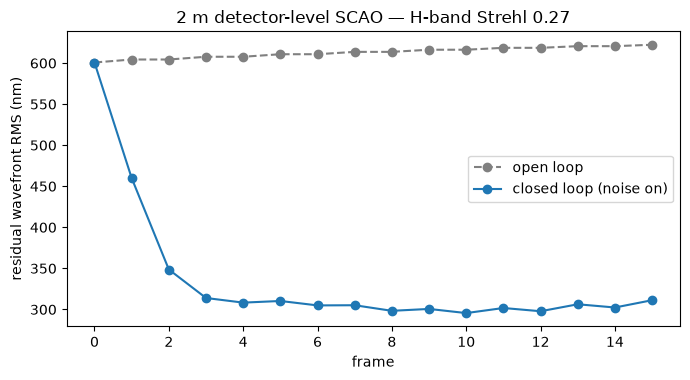

In [7]:
frames = np.arange(N_STEPS)
figure, axis = plt.subplots(figsize=(7.0, 3.9))
axis.plot(frames, open_loop * 1e9, "o--", color="0.5", label="open loop")
axis.plot(frames, closed_loop * 1e9, "o-", color="C0", label="closed loop (noise on)")
axis.set_xlabel("frame")
axis.set_ylabel("residual wavefront RMS (nm)")
axis.set_title(f"2 m detector-level SCAO — H-band Strehl {strehl:.2f}")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

With detector photon and read noise switched on, the shared loop engine still
converges on the 2 m aperture: the residual settles well below the open-loop
level and the leak keeps the integrator from drifting. The steady residual is
higher than the noise-free high-order study because measurement noise now adds
to fitting error, and the harder seeing (`D/r0 ≈ 11`) demands more of the DM.
Because this notebook and `high_order_scao.ipynb` call the identical
`run_closed_loop` function, the difference in outcome is attributable purely to
scale and noise, not to a different simulator.

## Limitations

- A single short realization; a delivered performance figure averages many
  seeds and longer sequences.
- The Strehl is the Maréchal estimate from residual RMS, not a propagated PSF.
- Read noise and photon budget are representative values, not tied to a
  specific instrument or guide-star magnitude.